## **Multi-Classification**
### **Import libraries**

In [1]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

### **Load Dataset**

In [2]:
print("Loading Fashion MNIST data...")
fashion_mnist = keras.datasets.fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']



Loading Fashion MNIST data...


### **Check Dataset Shape**

In [3]:
print("Training Data Shape:", x_train.shape)
print("Testing Data Shape:", x_test.shape)

Training Data Shape: (60000, 28, 28)
Testing Data Shape: (10000, 28, 28)


### **Displaying the First Image**

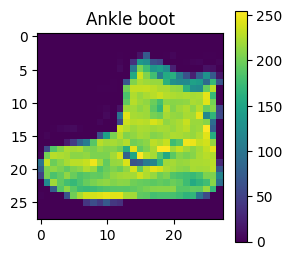

In [4]:
plt.figure(figsize=(3,3))
plt.imshow(x_train[0]) #, cmap='gray'
plt.title(class_names[y_train[0]])
plt.colorbar()
plt.show()

### **Normalization**

\ Generating Learning Visuals...


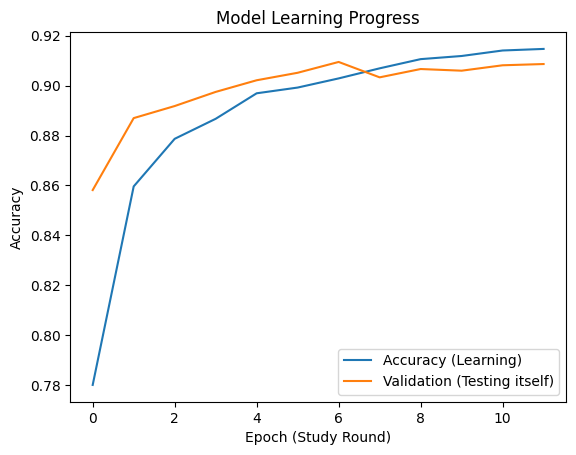

In [72]:
# --- Visualize the Learning Curve ---
print("\ Generating Learning Visuals...")
plt.plot(history.history['accuracy'], label='Accuracy (Learning)')
plt.plot(history.history['val_accuracy'], label='Validation (Testing itself)')
plt.title('Model Learning Progress')
plt.xlabel('Epoch (Study Round)')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [5]:
print(f"Normalizing pixels. Max value before: {x_train.max()}")
x_train = x_train / 255.0
x_test = x_test / 255.0
print(f"Max value after: {x_train.max()} (Data is now between 0 and 1)")


Normalizing pixels. Max value before: 255
Max value after: 1.0 (Data is now between 0 and 1)


### **Building the DL Model**

In [6]:
model = keras.Sequential([ 
    keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    keras.layers.MaxPooling2D((2,2)), 
    keras.layers.Dropout(0.25),
    keras.layers.Conv2D(64, (3,3), activation='relu'),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Dropout(0.25),
    keras.layers.Conv2D(128, (3,3), activation='relu'), 
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation = 'relu'),
    keras.layers.Dropout(0.25),
    keras.layers.Dense(10, activation = 'softmax')
    ])



C:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 3, 3, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1152)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 241,546 (943.54 KB)

 Trainable params: 241,546 (943.54 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

### **Training**

In [9]:
print("Starting Training..")
# We save the training progress into 'history'
history = model.fit(x_train, y_train, epochs=12, validation_split=0.1, verbose=1)

Starting Training..
Epoch 1/12
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 58s 31ms/step - accuracy: 0.7801 - loss: 0.5879 - val_accuracy: 0.8582 - val_loss: 0.3730
Epoch 2/12
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 46s 27ms/step - accuracy: 0.8596 - loss: 0.3825 - val_accuracy: 0.8870 - val_loss: 0.3039
Epoch 3/12
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 41s 24ms/step - accuracy: 0.8787 - loss: 0.3338 - val_accuracy: 0.8918 - val_loss: 0.2864
Epoch 4/12
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 40s 24ms/step - accuracy: 0.8867 - loss: 0.3076 - val_accuracy: 0.8975 - val_loss: 0.2711
Epoch 5/12
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 39s 23ms/step - accuracy: 0.8969 - loss: 0.2883 - val_accuracy: 0.9022 - val_loss: 0.2673
Epoch 6/12
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 39s 23ms/step - accuracy: 0.8992 - loss: 0.2752 - val_accuracy: 0.9052 - val_loss: 0.2528
Epoch 7/12
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 40s 24ms/step - accuracy: 0.9029 - loss: 0.2611 - val_accuracy: 0.9095 - val_loss: 0.2475
Epoch 8/12
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 40s 24ms/step 

### **Evaluation**

In [10]:
print("Testing on unseen images...")
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Final Accuracy: {test_acc*100:.2f}%")

Testing on unseen images...
Final Accuracy: 90.36%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
T-shirt/top: 49.14%
Trouser: 0.00%
Pullover: 0.00%
Dress: 0.01%
Coat: 0.01%
Sandal: 0.00%
Shirt: 50.84%
Sneaker: 0.00%
Bag: 0.00%
Ankle boot: 0.00%


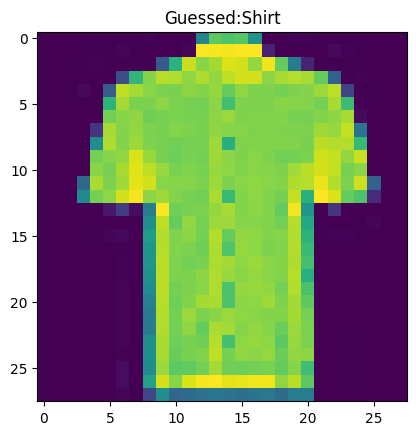

In [52]:
img_index = 40
img = x_test[img_index]
prediction = model.predict(np.expand_dims(img,0))

for i, score in enumerate(prediction[0]):
    print(f"{class_names[i]}: {score*100:.2f}%")

plt.imshow(img)
plt.title(f"Guessed:{class_names[np.argmax(prediction)]}")
plt.show()

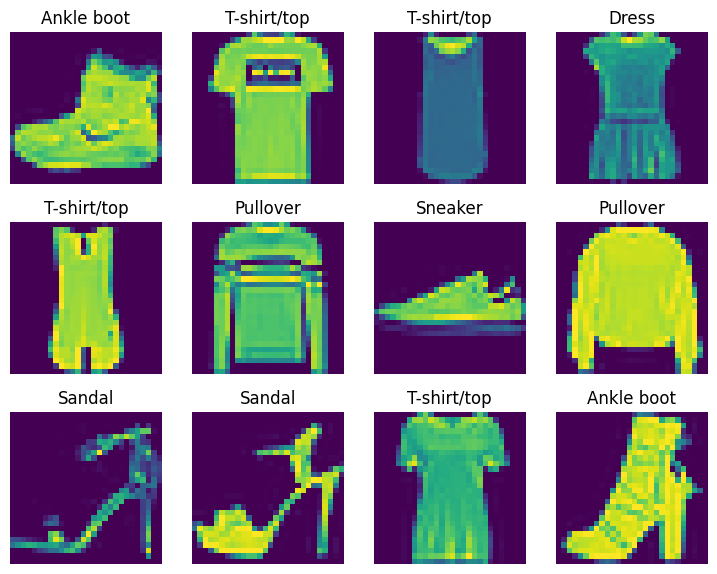

In [70]:
plt.figure(figsize = (9,7))

for i in range(0, 12):
    plt.subplot(3, 4, i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis('off')
   
plt.show()